In [14]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm, trange
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [15]:
data = pd.read_csv('dump3.csv')

In [16]:
data.shape

(83707, 5)

In [17]:
data.head(5)

,name,Артикул,category,Цена без карты,Цена с картой
0,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,"Главная,Каталог,Строительные материалы,Кровля,...",329.33 ₽,312.86 ₽
1,Аэратор ТЕХНОНИКОЛЬ КТВ,17575401,"Главная,Каталог,Строительные материалы,Кровля,...",1 529.00 ₽,1 452.55 ₽
2,Аэратор ТЕХНОНИКОЛЬ Pilot скатный,17575301,"Главная,Каталог,Строительные материалы,Кровля,...",3 008.00 ₽,2 857.60 ₽
3,Проходной элемент ТЕХНОНИКОЛЬ Shinglas,17575701,"Главная,Каталог,Строительные материалы,Кровля,...",1 172.00 ₽,1 113.40 ₽
4,Вентиль ТЕХНОНИКОЛЬ Skat кровельный,17575501,"Главная,Каталог,Строительные материалы,Кровля,...",2 396.00 ₽,2 276.20 ₽


In [19]:
print(data['category'].unique(), len(data['category'].unique()))

['Главная,Каталог,Строительные материалы,Кровля,Вентиляция для кровли'
 'Главная,Каталог,Строительные материалы,Кровля,Волнистый лист (ондулин)'
 'Главная,Каталог,Строительные материалы,Кровля,Кровельные мастики'
 'Главная,Каталог,Строительные материалы,Кровля,Кровельные ограждения, снегодержатели'
 'Главная,Каталог,Строительные материалы,Кровля,Металлочерепица'
 'Главная,Каталог,Строительные материалы,Кровля,Мягкая черепица'
 'Главная,Каталог,Строительные материалы,Кровля,Профнастил'
 'Главная,Каталог,Строительные материалы,Кровля,Рулонная кровля'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Затирки'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Клеи'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Ровнители для пола'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Специальные смеси'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Шпаклевки'
 'Главная,Катал

In [20]:
print(data['name'].unique(), len(data['name'].unique()))

['Проходка BORGE Кровельная D6-50мм прямая №1' 'Аэратор ТЕХНОНИКОЛЬ КТВ'
 'Аэратор ТЕХНОНИКОЛЬ Pilot скатный' ...
 'Решётка заборная FULEREN 15х15 0,5х5мх'
 'Решётка заборная FULEREN 15х15 0,5х10м'
 'Сетка сварная FULEREN Оцинкованная 50х100 1,8х15м'] 82921


# Выборка данных

In [93]:
topics = set(data.category)
pack_in_cat = 300

In [94]:
df_res = pd.DataFrame()

for topic in tqdm(topics):
    df_topic = data[data['category'] == topic][:pack_in_cat]
    df_res = df_res.append(df_topic)

  0%|          | 0/872 [00:00<?, ?it/s]

In [95]:
df_res.shape

(59701, 5)


# Предобработка

In [96]:
import string
def remove_punctuation(text):
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text):
    return ''.join([i if not i.isdigit() else ' ' for i in text])

import re
def remove_multiple_spaces(text):
	return re.sub(r'\s+', ' ', text, flags=re.I)

import nltk
nltk.download('stopwords')
from nltk.stem import *
from nltk.corpus import stopwords
from pymystem3 import Mystem
from string import punctuation
mystem = Mystem() 

russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...'])
def lemmatize_text(text):
    tokens = mystem.lemmatize(text.lower())
    tokens = [token for token in tokens if token not in russian_stopwords and token != " "]
    text = " ".join(tokens)
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mugichu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<ipython-input-97-6083d33376df>:26: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


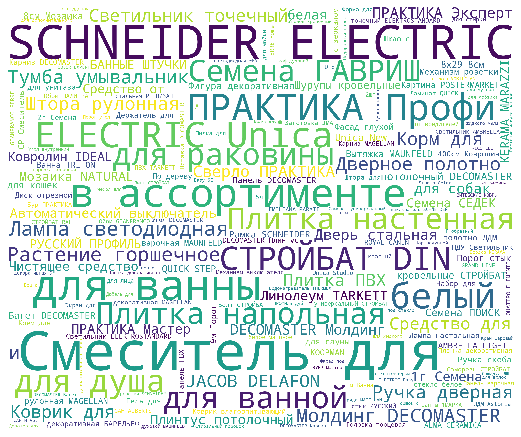

In [97]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus
# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus
# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',width=3000,height=2500,max_words=200,random_state=42).generate(str_corpus(corpus))
    return wordCloud

corpus = get_corpus(df_res['name'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [98]:
prep_text = [remove_multiple_spaces(remove_numbers(remove_punctuation(text.lower()))) for text in tqdm(df_res['name'])]


  0%|          | 0/59701 [00:00<?, ?it/s]

In [99]:
len(prep_text)
prep_text[1]

'коронка алмазная практика мастер мм '

In [100]:
df_res['text_prep'] = prep_text
df_res.head(1)

,name,Артикул,category,Цена без карты,Цена с картой,text_prep
9306,Коронка алмазная ПРАКТИКА Сделай сам 20мм 777-284,6603601,"Главная,Каталог,Инструменты и крепёж,Расходные...",411.00 ₽,390.45 ₽,коронка алмазная практика сделай сам мм


In [101]:
from nltk.stem.snowball import SnowballStemmer 
stemmer = SnowballStemmer("russian")

In [102]:
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...', 'т.д.', 'т', 'д','Главная','Каталог'])

In [103]:
import nltk
nltk.download('punkt')
from nltk import word_tokenize
text = df_res['text_prep'][0]
word_tokenize(text)

[nltk_data] Downloading package punkt to /home/mugichu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['проходка', 'borge', 'кровельная', 'd', 'мм', 'прямая', '№']

In [104]:
from nltk import word_tokenize

stemmed_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    stemmed_tokens = [stemmer.stem(token) for token in tokens if token not in russian_stopwords]
    text = " ".join(stemmed_tokens)
    stemmed_texts_list.append(text)

df_res['text_stem'] = stemmed_texts_list

  0%|          | 0/59701 [00:00<?, ?it/s]

In [105]:
def remove_stop_words(text):
    tokens = word_tokenize(text) 
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    return " ".join(tokens)

In [106]:
from nltk import word_tokenize

sw_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    text = " ".join(tokens)
    sw_texts_list.append(text)

df_res['text_sw'] = sw_texts_list

  0%|          | 0/59701 [00:00<?, ?it/s]

In [107]:
df_res['text_sw'][0]

'проходка borge кровельная d мм прямая №'

In [108]:
df_res.to_csv('sp_stemmed.csv')

In [109]:
df_res['text_stem'][0]

'проходк borge кровельн d мм прям №'

# Лемматизация

In [110]:
lemm_texts_list = []
for text in tqdm(df_res['text_sw']):
    #print(text)
    try:
        text_lem = mystem.lemmatize(text)
        tokens = [token for token in text_lem if token != ' ' and token not in russian_stopwords]
        text = " ".join(tokens)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df_res['text_lemm'] = lemm_texts_list

  0%|          | 0/59701 [00:00<?, ?it/s]

In [111]:
def lemmatize_text(text):
    text_lem = mystem.lemmatize(text)
    tokens = [token for token in text_lem if token != ' ']
    return " ".join(tokens)

In [112]:
df_res.to_csv('lemm.csv')

In [113]:
df_res = pd.read_csv('lemm.csv', encoding = 'utf-8')

In [114]:
df_res.head()

,Unnamed: 0,name,Артикул,category,Цена без карты,Цена с картой,text_prep,text_stem,text_sw,text_lemm
0,9306,Коронка алмазная ПРАКТИКА Сделай сам 20мм 777-284,6603601,"Главная,Каталог,Инструменты и крепёж,Расходные...",411.00 ₽,390.45 ₽,коронка алмазная практика сделай сам мм,коронк алмазн практик сдела мм,коронка алмазная практика сделай мм,коронка алмазный практика сделать мм \n
1,9307,Коронка алмазная ПРАКТИКА Мастер 30мм 777-307,6603801,"Главная,Каталог,Инструменты и крепёж,Расходные...",336.00 ₽,319.20 ₽,коронка алмазная практика мастер мм,коронк алмазн практик мастер мм,коронка алмазная практика мастер мм,коронка алмазный практика мастер мм \n
2,9308,Коронка алмазная ПРАКТИКА Мастер 25мм 777-291,6603701,"Главная,Каталог,Инструменты и крепёж,Расходные...",302.00 ₽,286.90 ₽,коронка алмазная практика мастер мм,коронк алмазн практик мастер мм,коронка алмазная практика мастер мм,коронка алмазный практика мастер мм \n
3,9309,Коронка алмазная ПРАКТИКА Мастер 35мм 777-314,6603901,"Главная,Каталог,Инструменты и крепёж,Расходные...",406.00 ₽,385.70 ₽,коронка алмазная практика мастер мм,коронк алмазн практик мастер мм,коронка алмазная практика мастер мм,коронка алмазный практика мастер мм \n
4,9310,Коронка биметаллическая ПРАКТИКА 32мм 035-950,3993001,"Главная,Каталог,Инструменты и крепёж,Расходные...",337.00 ₽,320.15 ₽,коронка биметаллическая практика мм,коронк биметаллическ практик мм,коронка биметаллическая практика мм,коронка биметаллический практика мм \n


In [115]:
df_res['text_lemm'][0]

'коронка алмазный практика сделать мм \n'

In [116]:
X = df_res['text_sw']
y = df_res['category']

In [117]:
type(df_res['text_lemm'][0])

str

In [209]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.95, random_state = 123)

In [210]:
my_cat = df_res['category'].unique()
my_cat

array(['Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Коронки',
       'Главная,Каталог,Обои,Обои 0,53',
       'Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Клей для потолочной плитки',
       'Главная,Каталог,Сад и огород,Ёмкости для растений,Кашпо',
       'Главная,Каталог,Товары для дома, подарки, бытовая химия,Техника для дома,Пылесосы',
       'Главная,Каталог,Сауны и бани,Аксессуары для саун и бань,Веники для бани',
       'Главная,Каталог,Товары для дома, подарки, бытовая химия,Бытовая химия,Репелленты',
       'Главная,Каталог,Инструменты и крепёж,Отделочный инструмент,Стеклорезы',
       'Главная,Каталог,Инженерная электрика, лампы,Кабели и провода,Провод ПГВА',
       'Главная,Каталог,Интерьер, текстиль, камины, оформление окон, картины,Оформление окон,Карнизы (гардины) готовые',
       'Главная,Каталог,Инструменты и крепёж,Крепёж и скобяные изделия,Верёвки, шнуры',
       'Главная,Каталог,Туризм и отдых,Товары для туризма и 

In [211]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [212]:
nb = Pipeline([('vect', CountVectorizer()),
               ('tfidf', TfidfTransformer()),
               ('clf', MultinomialNB()),
              ])

In [213]:
%%time
nb.fit(X_train, y_train)

CPU times: user 153 ms, sys: 63 µs, total: 153 ms
Wall time: 152 ms


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', MultinomialNB())])

In [214]:
%%time
from sklearn.metrics import classification_report
y_pred = nb.predict(X_test)

CPU times: user 506 ms, sys: 241 ms, total: 746 ms
Wall time: 745 ms


In [215]:
X_test.iloc[0]

'светильник светодиодный uniel растений ult p ul'

In [216]:
print(X_test.iloc[0], y_test.iloc[0], y_pred[0])

светильник светодиодный uniel растений ult p ul Главная,Каталог,Сад и огород,Горшечные растения, срезанные цветы, аксессуары,Светильники для растений Главная,Каталог,Освещение,Промышленные и технические светильники и комплектующие


In [217]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=127, max_iter=5, tol=None)),
               ])

In [218]:
%%time
sgd.fit(X_train, y_train)

CPU times: user 670 ms, sys: 0 ns, total: 670 ms
Wall time: 668 ms


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(alpha=0.001, max_iter=5, random_state=127,
                               tol=None))])

In [219]:
%%time
y_pred = sgd.predict(X_test)

CPU times: user 546 ms, sys: 176 ms, total: 722 ms
Wall time: 721 ms


In [220]:
from sklearn.metrics import accuracy_score
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred, target_names=my_cat))

accuracy 0.7118626137245222


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                         Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Коронки       0.66      0.54      0.59       117
                                                                                                           Главная,Каталог,Обои,Обои 0,53       0.43      1.00      0.60        34
                                           Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Клей для потолочной плитки       0.47      0.99      0.63        67
                                                                                  Главная,Каталог,Сад и огород,Ёмкости для растений,Кашпо       0.00      0.00      0.00         2
                                                        Главная,Каталог,Товары для дома, подарки, бытова

In [221]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=42, max_iter=5, tol=None)),
               ])

In [222]:
%%time
sgd.fit(X_train, y_train)

CPU times: user 687 ms, sys: 68 µs, total: 687 ms
Wall time: 685 ms


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(alpha=0.001, max_iter=5, random_state=42,
                               tol=None))])

In [223]:
%%time
y_pred = sgd.predict(X_test)

CPU times: user 521 ms, sys: 208 ms, total: 730 ms
Wall time: 728 ms


In [224]:
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred,target_names=my_cat))

accuracy 0.7111926087876437


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                         Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Коронки       0.67      0.55      0.60       117
                                                                                                           Главная,Каталог,Обои,Обои 0,53       0.45      1.00      0.62        34
                                           Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Клей для потолочной плитки       0.46      0.99      0.63        67
                                                                                  Главная,Каталог,Сад и огород,Ёмкости для растений,Кашпо       0.00      0.00      0.00         2
                                                        Главная,Каталог,Товары для дома, подарки, бытова

In [225]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', LogisticRegression(n_jobs=1, C=1e5)),
               ])

In [226]:
%%time
logreg.fit(X_train, y_train)

CPU times: user 52.8 s, sys: 2.77 s, total: 55.6 s
Wall time: 55.7 s


/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', LogisticRegression(C=100000.0, n_jobs=1))])

In [227]:
%%time
y_pred = logreg.predict(X_test)

CPU times: user 545 ms, sys: 252 ms, total: 797 ms
Wall time: 795 ms


In [228]:
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred,target_names=my_cat))

accuracy 0.7484836730375908


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                         Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Коронки       0.54      0.62      0.58       117
                                                                                                           Главная,Каталог,Обои,Обои 0,53       0.54      1.00      0.70        34
                                           Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Клей для потолочной плитки       0.74      0.88      0.80        67
                                                                                  Главная,Каталог,Сад и огород,Ёмкости для растений,Кашпо       0.00      0.00      0.00         2
                                                        Главная,Каталог,Товары для дома, подарки, бытова

In [324]:
test_text ='дверь'

In [325]:
test_text = remove_multiple_spaces(remove_numbers(remove_punctuation(test_text.lower())))
test_text = remove_stop_words(test_text)

In [326]:
%%time
test_text = lemmatize_text(test_text)

CPU times: user 593 µs, sys: 35 µs, total: 628 µs
Wall time: 457 µs


In [327]:
test_text

'дверь \n'

In [328]:
test_pred = logreg.predict([test_text])
test_pred

array(['Главная,Каталог,Двери, окна, замки,Двери стальные'], dtype=object)

In [329]:
plt.figure(figsize=(12,7))
plt.plot(Rs,'ro')
plt.plot(Gs,'g.')
plt.plot(Bs,'b:')
plt.yscale('log')
plt.ylabel("Singular vals")
plt.show()

NameError: name 'Rs' is not defined

<Figure size 864x504 with 0 Axes>